In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
!kaggle datasets download mexwell/fake-reviews-dataset

Dataset URL: https://www.kaggle.com/datasets/mexwell/fake-reviews-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 4.78M/4.78M [00:00<00:00, 89.6MB/s]



In [4]:
import zipfile
with zipfile.ZipFile("fake-reviews-dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

In [5]:
df = pd.read_csv("fake reviews dataset.csv")

In [6]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


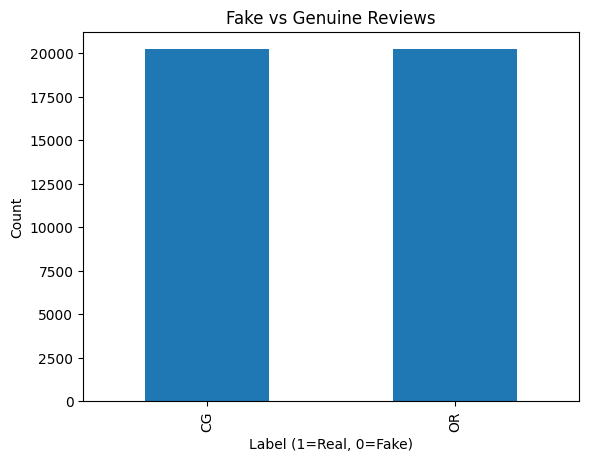

In [7]:
df["label"].value_counts().plot(kind="bar")
plt.title("Fake vs Genuine Reviews")
plt.xlabel("Label (1=Real, 0=Fake)")
plt.ylabel("Count")
plt.show()

In [10]:

df = df.rename(columns={
    "text_": "review_text"})


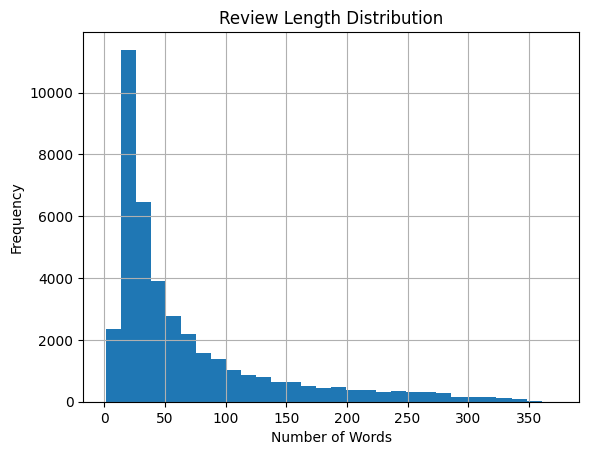

In [11]:
df["length"] = df["review_text"].apply(lambda x: len(str(x).split()))
df["length"].hist(bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

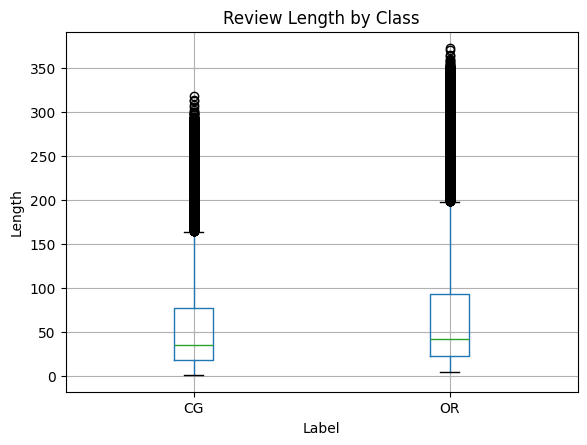

In [12]:
df.boxplot(column="length", by="label")
plt.title("Review Length by Class")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Length")
plt.show()

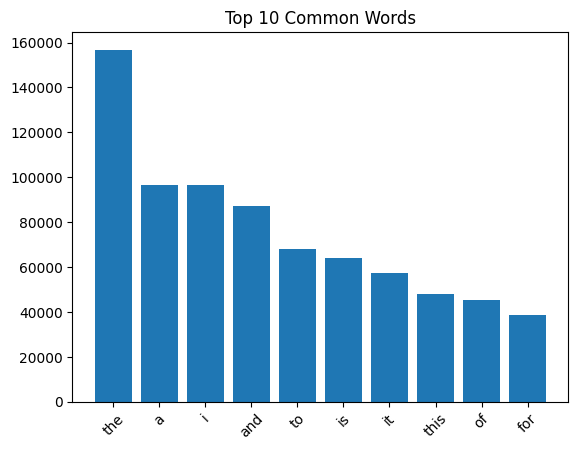

In [13]:
from collections import Counter

all_words = " ".join(df["review_text"]).lower().split()
common_words = Counter(all_words).most_common(10)

words, counts = zip(*common_words)

plt.bar(words, counts)
plt.title("Top 10 Common Words")
plt.xticks(rotation=45)
plt.show()

In [18]:
fake_words = " ".join(df[df["label"]=="OR"]["review_text"]).lower().split()
real_words = " ".join(df[df["label"]=="CG"]["review_text"]).lower().split()

fake_common = Counter(fake_words).most_common(10)
real_common = Counter(real_words).most_common(10)

print("Fake review words:", fake_common)
print("Real review words:", real_common)

Fake review words: [('the', 73074), ('and', 44011), ('a', 39874), ('i', 39622), ('to', 37655), ('it', 26403), ('of', 25038), ('is', 23941), ('this', 21625), ('for', 18229)]
Real review words: [('the', 83693), ('a', 56859), ('i', 56824), ('and', 43213), ('is', 40268), ('it', 31024), ('to', 30478), ('this', 26274), ('of', 20364), ('for', 20256)]


In [17]:
print(df['label'].value_counts())

label
CG    20216
OR    20216
Name: count, dtype: int64


In [20]:
import nltk
from nltk.corpus import stopwords
import re

try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')


stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = str(text).lower().split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

In [21]:
df['review_text_cleaned'] = df['review_text'].apply(remove_stopwords)

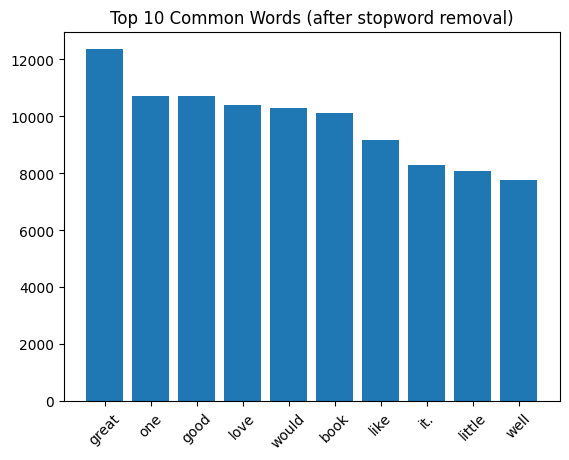

In [22]:
all_words_cleaned = " ".join(df["review_text_cleaned"]).lower().split()
common_words_cleaned = Counter(all_words_cleaned).most_common(10)

words_cleaned, counts_cleaned = zip(*common_words_cleaned)

plt.bar(words_cleaned, counts_cleaned)
plt.title("Top 10 Common Words (after stopword removal)")
plt.xticks(rotation=45)
plt.show()

In [23]:
fake_words_cleaned = " ".join(df[df["label"]=="OR"]["review_text_cleaned"]).lower().split()
real_words_cleaned = " ".join(df[df["label"]=="CG"]["review_text_cleaned"]).lower().split()

fake_common_cleaned = Counter(fake_words_cleaned).most_common(10)
real_common_cleaned = Counter(real_words_cleaned).most_common(10)

print("Fake review words (cleaned):", fake_common_cleaned)
print("Real review words (cleaned):", real_common_cleaned)

Fake review words (cleaned): [('one', 5879), ('like', 5057), ('great', 4709), ('would', 4276), ('good', 4032), ('book', 3729), ('love', 3663), ('get', 3461), ('really', 3433), ('it.', 2919)]
Real review words (cleaned): [('great', 7649), ('love', 6718), ('good', 6663), ('book', 6400), ('would', 6025), ('it.', 5363), ('little', 5301), ('story', 5052), ('well', 4987), ('one', 4842)]
